# Evaluation

In [3]:
from pydantic import BaseModel
import json

def read_json(file_path : str) -> dict:
    with open(file_path, 'r') as f:
        return json.load(f)

In [4]:
import os

goal_settings = {}
analysises = {}

for dir in os.listdir('./results'):
    file_path = os.path.join('./results', dir, 'goal_setting.json')
    if os.path.exists(file_path):
        analysises[dir] = read_json(os.path.join('./results', dir, 'analysis.json'))
        goal_settings[dir] = read_json(file_path)

## Heatmap

In [5]:
import pandas as pd

data = {}

for district, goal_setting in goal_settings.items():
    d = {}
    for goal in goal_setting['goals']:
        for task in goal['tasks']:
            for indicator in task['indicators']:
                code = indicator['code']
                d[code] = True
    data[district] = d

df = pd.DataFrame.from_dict(data).fillna(False)

/tmp/ipykernel_70209/31917210.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame.from_dict(data).fillna(False)


In [6]:
indicators_df = pd.read_excel('./data/indicators.xlsx').set_index('Код показателя', drop=True)

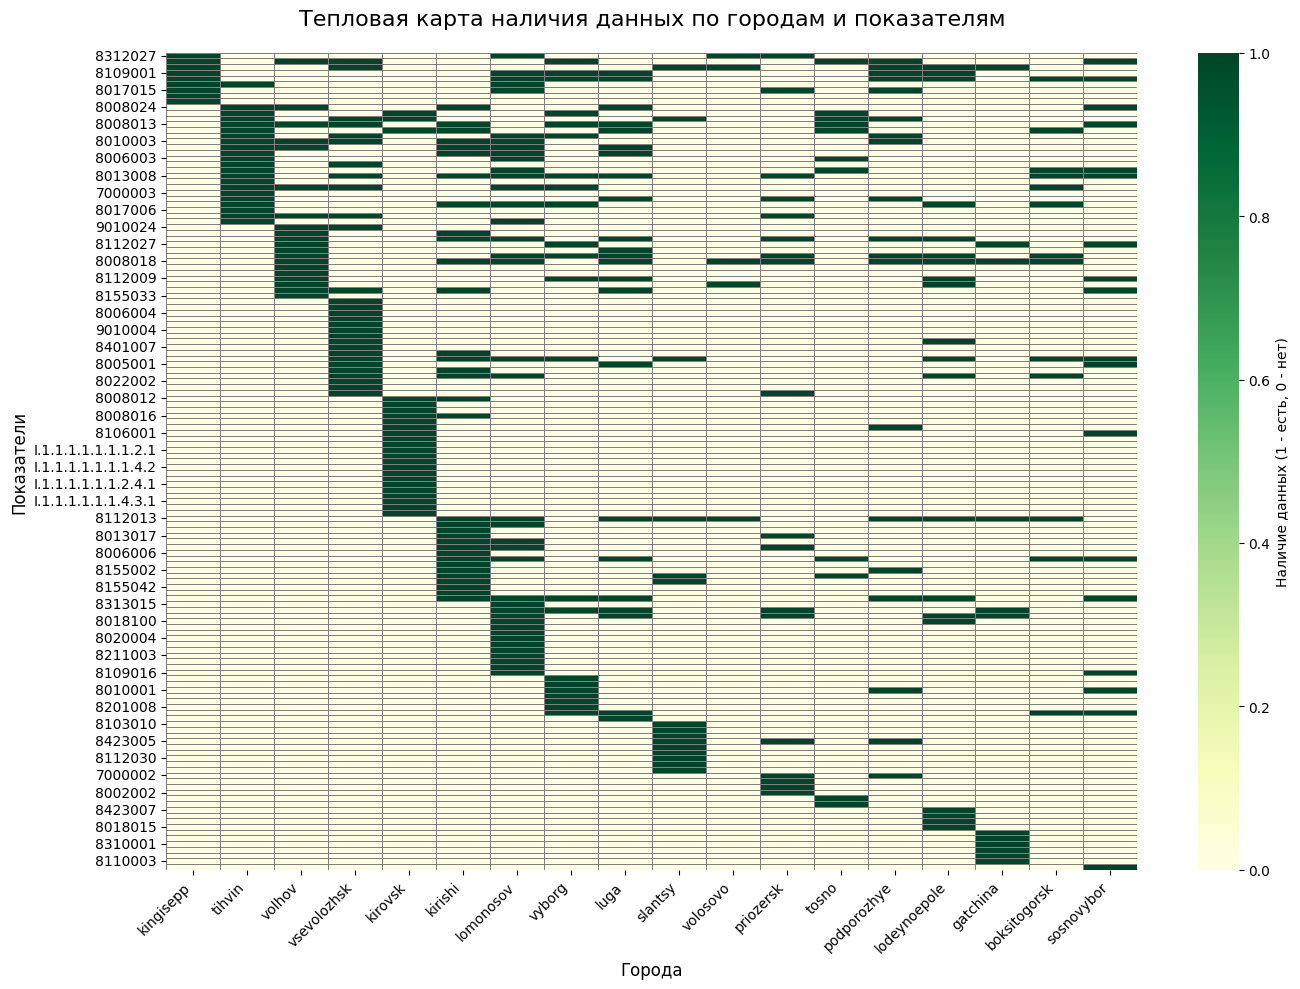

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагается, что у вас уже есть df:
# - столбцы — города (kingisepp, volhov, ...)
# - строки — показатели
# - значения — True/False

# Создаем тепловую карту
plt.figure(figsize=(14, 10))

# Преобразуем True/False в 1/0 для визуализации
heatmap_data = df.astype(int)

# Рисуем тепловую карту
sns.heatmap(
    heatmap_data,
    annot=False,  # показывать значения (1 или 0)
    fmt='d',     # целые числа
    cmap='YlGn',  # красный (0) -> зеленый (1)
    cbar_kws={'label': 'Наличие данных (1 - есть, 0 - нет)'},
    linewidths=0.5,
    linecolor='gray'
)

# Настройка подписей
plt.title('Тепловая карта наличия данных по городам и показателям', fontsize=16, pad=20)
plt.xlabel('Города', fontsize=12)
plt.ylabel('Показатели', fontsize=12)

# Поворачиваем подписи городов для читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Подгоняем layout
plt.tight_layout()

# Показываем график
plt.show()

## G-Eval

In [12]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

CRITERIA = """
Оцени ТОЛЬКО смысловое соответствие ответа ожидаемому документу.
ИГНОРИРУЙ:
- форматирование, заголовки, маркированные списки
- наличие или отсутствие конкретных разделов, пунктов, показателей, задач, приоритетов, направлений
- структуру документа
"""

# Создаём G-Eval метрику для оценки ответа
geval_metric = GEval(
    name="StrategyQuality",
    criteria=CRITERIA,
    evaluation_params=[
        LLMTestCaseParams.EXPECTED_OUTPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT
    ],
    evaluation_steps= [
        "Сравни смысловое содержание Expected Output и Actual Output.",
        "Определи, передают ли оба документа одну и ту же основную информацию и идеи.",
        "Игнорируй различия в форматировании, структуре и наличии/отсутствии разделов.",
        "Оцени только соответствие смысла между Expected Output и Actual Output."
    ],
    threshold=0.8,
    model="openai/gpt-4.1",
)

test_cases = []

def read_txt(file_path : str) -> str:
    with open(file_path, 'r', encoding='utf-8') as f:
        return f.read().strip()

for dir in os.listdir('./results'):
    expected_output = read_txt(os.path.join('./results', dir, 'actual.txt'))
    actual_output = read_json(os.path.join('./results', dir, 'goal_setting.json'))
    test_case = LLMTestCase(
        name=dir,
        input=dir,
        actual_output=str(actual_output),
        expected_output=str(expected_output)
    )
    test_cases.append(test_case)

In [13]:
from deepeval import evaluate
from deepeval.evaluate import AsyncConfig, DisplayConfig, ErrorConfig

async_config = AsyncConfig(
    run_async=True,        # включает параллельное выполнение
    max_concurrent=10      # максимальное количество параллельных тест-кейсов
)

# Настройка отображения результатов
display_config = DisplayConfig(
    print_results=True,    # печатает результаты каждого теста
    show_indicator=True,   # показывает прогресс-бар
    verbose_mode=False,    # отключает подробный вывод метрик (можете включить при отладке)
)

error_config = ErrorConfig(
    ignore_errors=False,   # не игнорировать ошибки (при True продолжит выполнение)
    skip_on_missing_params=False  # не пропускать тесты с отсутствующими параметрами
)

results = evaluate(
    test_cases=test_cases,
    metrics=[geval_metric],
    async_config=async_config,
    display_config=display_config,
    error_config=error_config
)

✨ You're running DeepEval's latest StrategyQuality [GEval] Metric! (using openai/gpt-4.1, strict=False, 
async_mode=True)...

Output()



Metrics Summary

  - ❌ StrategyQuality [GEval] (score: 0.3, threshold: 0.8, strict: False, evaluation model: openai/gpt-4.1, reason: The Actual Output partially aligns with the Expected Output by mentioning the mission, goals, and some strategic directions such as economic diversification, infrastructure improvement, and quality of life. However, it omits key conceptual elements from the Expected Output, such as the emphasis on the territory's competitive advantages, the role of the city of Slantsy, the supporting role of the agro-industrial sector, and the project-based approach. The Actual Output is more focused on specific tasks, indicators, and factors, lacking the broader strategic vision and qualitative priorities described in the Expected Output., error: None)

For test case:

  - input: slantsy
  - actual output: {'external_factors': ['Развитие портовой инфраструктуры Усть-Луги и транспортных коридоров', 'Участие в общеобластных программах развития Ленинградской области', 'Не

⚠ WARNING: No hyperparameters logged.
» ]8;id=907486;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 9.06s | token cost: None)
» Test Results (18 total tests):
   » Pass Rate: 11.11% | Passed: 2 | Failed: 16

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

In [16]:
import numpy
numpy.mean([t.metrics_data[0].score for t in results.test_results])

np.float64(0.5333333333333333)

In [14]:
results.test_results

[TestResult(name='slantsy', success=False, metrics_data=[MetricData(name='StrategyQuality [GEval]', threshold=0.8, success=False, score=0.3, reason="The Actual Output partially aligns with the Expected Output by mentioning the mission, goals, and some strategic directions such as economic diversification, infrastructure improvement, and quality of life. However, it omits key conceptual elements from the Expected Output, such as the emphasis on the territory's competitive advantages, the role of the city of Slantsy, the supporting role of the agro-industrial sector, and the project-based approach. The Actual Output is more focused on specific tasks, indicators, and factors, lacking the broader strategic vision and qualitative priorities described in the Expected Output.", strict_mode=False, evaluation_model='openai/gpt-4.1', error=None, evaluation_cost=None, verbose_logs='Criteria:\n\nОцени ТОЛЬКО смысловое соответствие ответа ожидаемому документу.\nИГНОРИРУЙ:\n- форматирование, заголов

## Contextual

In [10]:
from deepeval.test_case import LLMTestCase
from deepeval.metrics import FaithfulnessMetric, HallucinationMetric

# Инициализация метрик через ваш RouterAI
faithfulness_metric = FaithfulnessMetric(
    threshold=0.5,
    model="openai/gpt-4o-mini",
    include_reason=True
)

hallucination_metric = HallucinationMetric(
    threshold=0.5,
    model="openai/gpt-4o-mini",
    include_reason=True
)

test_cases = []

for dir in os.listdir('./results'):
    context = read_json(os.path.join('./results', dir, 'analysis.json'))
    expected_output = read_json(os.path.join('./results', dir, 'goal_setting.json'))
    test_case = LLMTestCase(
        name=dir,
        input=dir,
        actual_output=str(expected_output),
        expected_output=str(expected_output),
        context=[str(context)],
        retrieval_context=[str(context)]
    )
    test_cases.append(test_case)

In [ ]:
from deepeval import evaluate
from deepeval.evaluate import AsyncConfig, DisplayConfig, ErrorConfig

async_config = AsyncConfig(
    run_async=True,        # включает параллельное выполнение
    max_concurrent=10      # максимальное количество параллельных тест-кейсов
)

# Настройка отображения результатов
display_config = DisplayConfig(
    print_results=True,    # печатает результаты каждого теста
    show_indicator=True,   # показывает прогресс-бар
    verbose_mode=False,    # отключает подробный вывод метрик (можете включить при отладке)
)

error_config = ErrorConfig(
    ignore_errors=False,   # не игнорировать ошибки (при True продолжит выполнение)
    skip_on_missing_params=False  # не пропускать тесты с отсутствующими параметрами
)

results = evaluate(
    test_cases=test_cases,
    metrics=[faithfulness_metric, hallucination_metric],
    async_config=async_config,
    display_config=display_config,
    error_config=error_config
)

✨ You're running DeepEval's latest Faithfulness Metric! (using openai/gpt-4o-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Hallucination Metric! (using openai/gpt-4o-mini, strict=False, 
async_mode=True)...

Output()

In [ ]:
results

In [94]:
# from deepeval.test_case import LLMTestCase
# from deepeval.metrics import FaithfulnessMetric, HallucinationMetric
# from tqdm import tqdm
# import pandas as pd

# # Инициализация метрик через ваш RouterAI
# faithfulness_metric = FaithfulnessMetric(
#     threshold=0.5,
#     model="openai/gpt-4o-mini",
#     include_reason=True
# )

# hallucination_metric = HallucinationMetric(
#     threshold=0.5,
#     model="openai/gpt-4o-mini",
#     include_reason=True
# )

# results = []

# for key in tqdm(analysises.keys(), desc="Оценка галлюцинаций"):
#     # Берем контекст и ответ по одному ключу
#     context = []
#     for k,d in analysises[key].items():
#         for k_,v in d.items():
#             context.append(v)
#     response = goal_settings[key]
    
#     # Создаем тестовый кейс
#     test_case = LLMTestCase(
#         input=key,  # или сам запрос, если он у вас есть отдельно
#         actual_output=str(response),
#         retrieval_context=context,  # для Faithfulness
#         context=context              # для Hallucination
#     )
    
#     # Запускаем обе метрики
#     faithfulness_metric.measure(test_case)
#     hallucination_metric.measure(test_case)
    
#     # Сохраняем результаты
#     results.append({
#         "query_key": key,
#         "response": response[:200] + "..." if len(response) > 200 else response,
#         "context_length": len(context),
#         "faithfulness_score": faithfulness_metric.score,
#         "faithfulness_passed": faithfulness_metric.is_successful(),
#         "faithfulness_reason": faithfulness_metric.reason,
#         "hallucination_score": hallucination_metric.score,
#         "hallucination_passed": hallucination_metric.is_successful(),
#         "hallucination_reason": hallucination_metric.reason
#     })

# # Превращаем в DataFrame для анализа
# df_results = pd.DataFrame(results)

# # Выводим статистику
# print(f"\n=== СТАТИСТИКА ===")
# print(f"Всего оценено: {len(df_results)}")
# print(f"\nFaithfulness:")
# print(f"  Средний score: {df_results['faithfulness_score'].mean():.3f}")
# print(f"  Прошли порог: {df_results['faithfulness_passed'].sum()}/{len(df_results)} ({df_results['faithfulness_passed'].mean()*100:.1f}%)")
# print(f"\nHallucination:")
# print(f"  Средний score: {df_results['hallucination_score'].mean():.3f}")
# print(f"  Прошли порог: {df_results['hallucination_passed'].sum()}/{len(df_results)} ({df_results['hallucination_passed'].mean()*100:.1f}%)")

# # Показываем проблемные кейсы
# print(f"\n=== ПРОБЛЕМНЫЕ КЕЙСЫ (hallucination > 0.5) ===")
# problematic = df_results[df_results['hallucination_score'] > 0.5]
# for _, row in problematic.iterrows():
#     print(f"  {row['query_key']}: hallucination={row['hallucination_score']:.2f}")